##Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Load Dataset

In [4]:
df = pd.read_csv('User_Data.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
x = df.iloc[:,[2,3]]
y = df.iloc[:,4]

##Train-test split

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

##Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

##Model training

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [9]:
LogisticRegression(C=1.0,class_weight=None,dual=False,        #c indicates the inverse of the reguralization, the smaller the value, the stronger is our regularization
                                                              #class_weight is used for imbalanced classes
                   fit_intercept=True,multi_class='warn',     #fit intercept is used to get the bias
                   n_jobs=None,penalty='l2',random_state=0,   #n_jobs - indicates how many cores of the cpu is used while running this, none means one core is used
                                                              #penalty = 'l2' - here l2 or ridge regularization is used
                   solver='warn',tol=0.0001,verbose=0,warm_start=False)  #tol - tolerance of the regularization-when to stop

LogisticRegression(multi_class='warn', random_state=0, solver='warn')

##Prediction

In [10]:
y_pred = model.predict(x_test)

##Model evaluaton

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)

acc = accuracy_score(y_test, y_pred)
print(f"Accurary = {acc}")

[[49  3]
 [ 8 20]]
Accurary = 0.8625


##Plotting

/tmp/ipykernel_303/150123982.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j,0], x_set[y_set == j, 1], c = ListedColormap(('navy', 'steelblue'))(i), label = j)


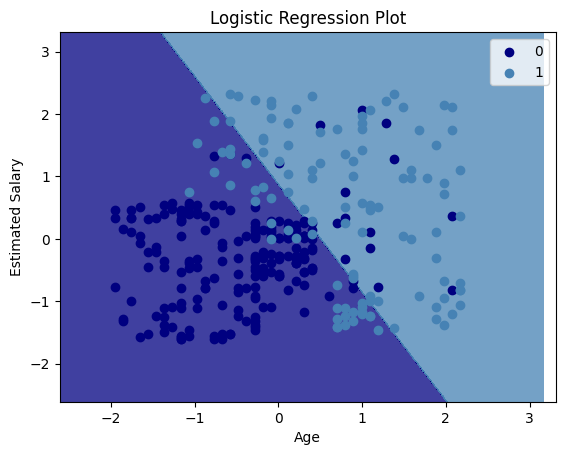

In [17]:
#for training sets
from matplotlib.colors import ListedColormap
x_set, y_set = x_train, y_train
x1, x2 = np.meshgrid(np.arange(start = x_set[:,0].min() - 1, stop = x_set[:,0].max() + 1, step = 0.01), #Here we have a 2D meshgrid(array), we did -1 and +1 to get the grid beyond the minimum and maximum values.
                     np.arange(start = x_set[:,1].min() - 1, stop = x_set[:,1].max() + 1, step = 0.01))
plt.contourf(x1, x2, model.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape), #ravel() used to tranform the 2D array to 1D, then we took the transpose and then reshaped it back to 2D
             alpha = 0.75, cmap = ListedColormap(('navy', 'steelblue')))                      #contour is used to shaow the density like kde but as circles.
plt.xlim(x1.min(), x1.max())
plt.xlim(x2.min(), x2.max())


for i, j in enumerate(np.unique(y_set)):   #enumerate give the index values and also the item with the index.
  plt.scatter(x_set[y_set == j,0], x_set[y_set == j, 1], c = ListedColormap(('navy', 'steelblue'))(i), label = j)
plt.title('Logistic Regression Plot')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

/tmp/ipykernel_303/3950315838.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j,0], x_set[y_set == j, 1], c = ListedColormap(('navy', 'steelblue'))(i), label = j)


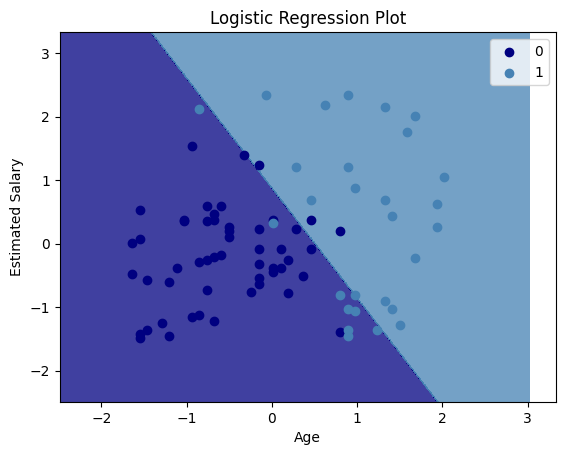

In [16]:
#for testing sets
from matplotlib.colors import ListedColormap
x_set, y_set = x_test, y_test
x1, x2 = np.meshgrid(np.arange(start = x_set[:,0].min() - 1, stop = x_set[:,0].max() + 1, step = 0.01), .
                     np.arange(start = x_set[:,1].min() - 1, stop = x_set[:,1].max() + 1, step = 0.01))
plt.contourf(x1, x2, model.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha = 0.75, cmap = ListedColormap(('navy', 'steelblue')))
plt.xlim(x1.min(), x1.max())
plt.xlim(x2.min(), x2.max())


for i, j in enumerate(np.unique(y_set)):
  plt.scatter(x_set[y_set == j,0], x_set[y_set == j, 1], c = ListedColormap(('navy', 'steelblue'))(i), label = j)
plt.title('Logistic Regression Plot')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()